In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# consider import plotly.express as px

In [ ]:
url = 'https://raw.githubusercontent.com/hankike/Premier_Prediction/refs/heads/main/data/cleaned_premier.csv'

df_premier = pd.read_csv(url)

# Shots per game tables

First we need to make a shots per game table `shots_table` and a shots allowed per game table `shots_against_table`

In [14]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_for = home_games["FTHG"].sum()
    home_shots_for = home_games["HS"].sum()

    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_for = away_games["FTAG"].sum()
    away_shots_for = away_games["AS"].sum()
    
    records.append({
        "Team": team,
        "Games": len(home_games) + len(away_games),
        "Shots Home": home_shots_for,
        "Goals Home": home_goals_for,
        "Home Shots per Goal": home_shots_for / home_goals_for if home_goals_for > 0 else 0,
        "Home Shots per Game": home_shots_for / (len(home_games) if len(home_games) > 0 else 1),
        "Shots Away": away_shots_for,
        "Goals Away": away_goals_for,
        "Away Shots per Goal": away_shots_for / away_goals_for if away_goals_for > 0 else 0,
        "Away Shots per Game": away_shots_for / (len(away_games) if len(away_games) > 0 else 1)
    })


shots_table = pd.DataFrame(records)

shots_table["Home Shots per Goal"] = shots_table["Home Shots per Goal"].round(2)

shots_table["Home Shots per Game"] = shots_table["Home Shots per Game"].round(2)

shots_table["Away Shots per Goal"] = shots_table["Away Shots per Goal"].round(2)

shots_table["Away Shots per Game"] = shots_table["Away Shots per Game"].round(2)

shots_table = shots_table.sort_values(
    "Home Shots per Goal",
    ascending=True
).reset_index(drop=True)

shots_table

,Team,Games,Shots Home,Goals Home,Home Shots per Goal,Home Shots per Game,Shots Away,Goals Away,Away Shots per Goal,Away Shots per Game
0,Man City,266,2394,357,6.71,18.00,2165,266,8.14,16.28
1,Brentford,190,1194,159,7.51,12.57,964,124,7.77,10.15
2,Tottenham,266,1863,241,7.73,14.01,1552,213,7.29,11.67
3,Arsenal,266,2143,272,7.88,16.11,1663,219,7.59,12.50
4,West Ham,266,1607,202,7.96,12.08,1515,163,9.29,11.39
5,Aston Villa,266,1813,227,7.99,13.63,1523,162,9.40,11.45
6,Leicester,190,1130,141,8.01,11.89,1078,140,7.70,11.35
7,Liverpool,266,2482,301,8.25,18.66,2077,256,8.11,15.62
8,Newcastle,266,1945,233,8.35,14.62,1433,169,8.48,10.77
9,Man United,266,2135,239,8.93,16.05,1702,185,9.20,12.80


In [16]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_against = home_games["FTAG"].sum()
    home_shots_against = home_games["AS"].sum()

    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_against = away_games["FTHG"].sum()
    away_shots_against = away_games["HS"].sum()
    
    records.append({
        "Team": team,
        "Games": len(home_games) + len(away_games),
        "Shots Allowed Home": home_shots_against,
        "Goals Allowed Home": home_goals_against,
        "Home Opp Shots per Goal": home_shots_against / home_goals_against if home_goals_against > 0 else 0,
        "Home Opp Shots per Game": home_shots_against / (len(home_games) if len(home_games) > 0 else 1),
        "Shots Allowed Away": away_shots_against,
        "Goals Allowed Away": away_goals_against,
        "Away Opp Shots per Goal": away_shots_against / away_goals_against if away_goals_against > 0 else 0,
        "Away Opp Shots per Game": away_shots_against / (len(away_games) if len(away_games) > 0 else 1)
    })


shots_against_table = pd.DataFrame(records)

shots_against_table["Home Opp Shots per Goal"] = shots_against_table["Home Opp Shots per Goal"].round(2)

shots_against_table["Home Opp Shots per Game"] = shots_against_table["Home Opp Shots per Game"].round(2)

shots_against_table["Away Opp Shots per Goal"] = shots_against_table["Away Opp Shots per Goal"].round(2)

shots_against_table["Away Opp Shots per Game"] = shots_against_table["Away Opp Shots per Game"].round(2)

shots_against_table = shots_against_table.sort_values(
    "Home Opp Shots per Goal",
    ascending=False
).reset_index(drop=True)

shots_against_table

,Team,Games,Shots Allowed Home,Goals Allowed Home,Home Opp Shots per Goal,Home Opp Shots per Game,Shots Allowed Away,Goals Allowed Away,Away Opp Shots per Goal,Away Opp Shots per Game
0,Sunderland,38,227,20,11.35,11.95,315,28,11.25,16.58
1,Nott'm Forest,152,964,93,10.37,12.68,1143,139,8.22,15.04
2,Liverpool,266,1181,115,10.27,8.88,1399,168,8.33,10.52
3,Newcastle,266,1650,167,9.88,12.41,1873,212,8.83,14.08
4,Brentford,190,1269,129,9.84,13.36,1493,147,10.16,15.72
5,Bournemouth,190,1184,122,9.70,12.46,1499,181,8.28,15.78
6,Everton,266,1589,169,9.40,11.95,1990,203,9.80,14.96
7,Man United,266,1474,157,9.39,11.08,1846,185,9.98,13.88
8,Arsenal,266,1230,131,9.39,9.25,1500,137,10.95,11.28
9,Tottenham,266,1610,174,9.25,12.11,1885,204,9.24,14.17


# Comparing Our Data

Now we want to look at a visual showing how the teams relate to shots per goal and shots per game, both for and against them

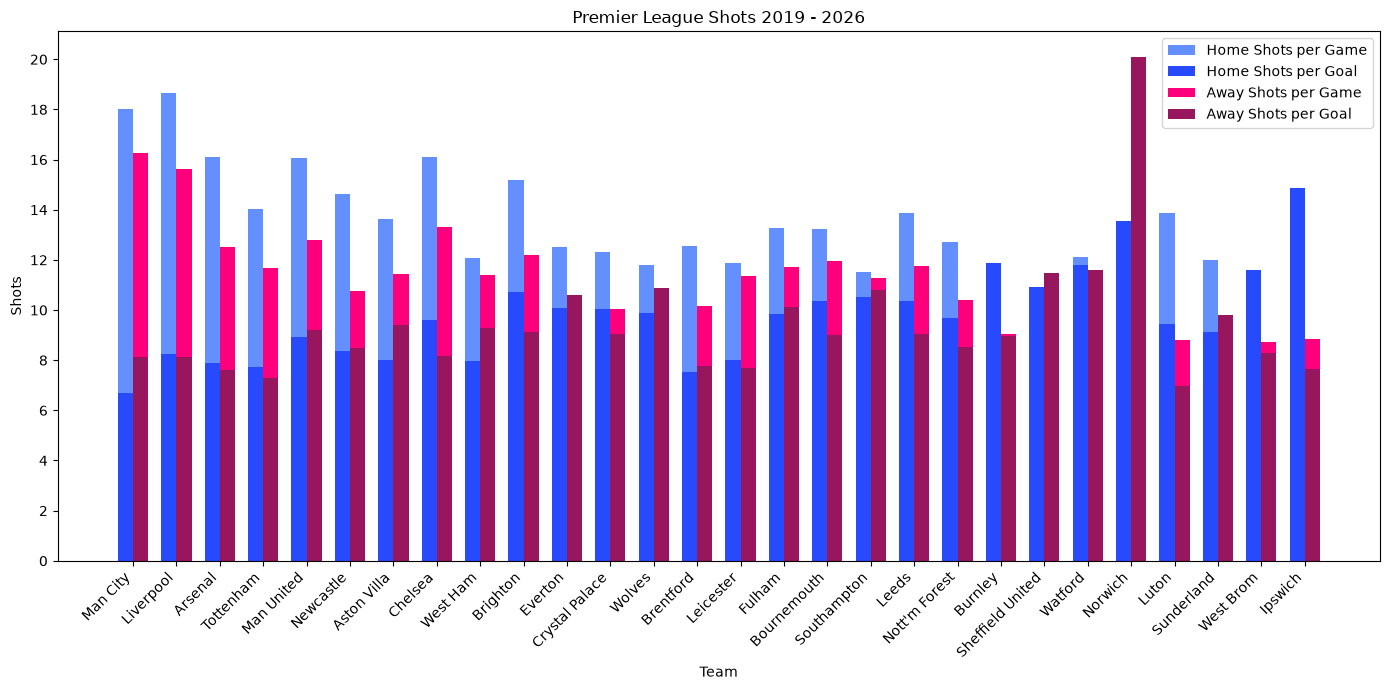

In [5]:
x = np.arange(len(shots_table["Games"]))

width = 0.35

plt.figure(figsize=(14, 7))

# Home bar
plt.bar(
    x - width/2,
    shots_table["Home Shots per Game"],
    width=width,
    color = '#648fff',
    label="Home Shots per Game"
)

plt.bar(
    x - width/2,
    shots_table["Home Shots per Goal"],
    width=width,
    color = '#274bfc',
    label="Home Shots per Goal"
)

# Away bar
plt.bar(
    x + width/2,
    shots_table["Away Shots per Game"],
    width=width,
    color = '#ff007d',
    label="Away Shots per Game"
)

plt.bar(
    x + width/2,
    shots_table["Away Shots per Goal"],
    width=width,
    color = '#98165d',
    label="Away Shots per Goal"
)

plt.xlabel("Team")
plt.ylabel("Shots")
plt.title("Premier League Shots 2019 - 2026")

plt.xticks(x, shots_table["Team"], rotation=45, ha="right")
plt.yticks(np.arange(0, 21, 2))

plt.legend()

plt.tight_layout()
plt.show()

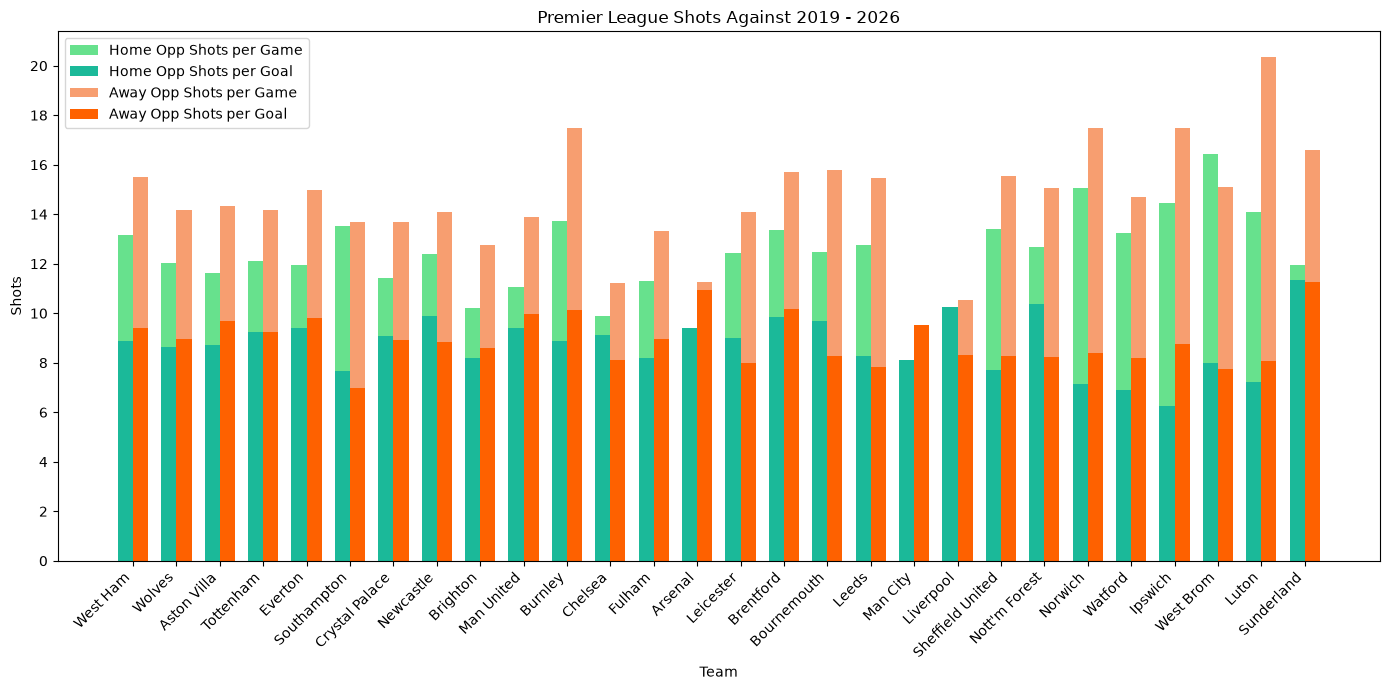

In [7]:
x = np.arange(len(shots_against_table["Games"]))

width = 0.35

plt.figure(figsize=(14, 7))

# Home bar
plt.bar(
    x - width/2,
    shots_against_table["Home Opp Shots per Game"],
    width=width,
    color = '#67e18d',
    label="Home Opp Shots per Game"
)

plt.bar(
    x - width/2,
    shots_against_table["Home Opp Shots per Goal"],
    width=width,
    color = '#1bb999',
    label="Home Opp Shots per Goal"
)

# Away bar
plt.bar(
    x + width/2,
    shots_against_table["Away Opp Shots per Game"],
    width=width,
    color = '#f79e70',
    label="Away Opp Shots per Game"
)

plt.bar(
    x + width/2,
    shots_against_table["Away Opp Shots per Goal"],
    width=width,
    color = '#fe6100',
    label="Away Opp Shots per Goal"
)

plt.xlabel("Team")
plt.ylabel("Shots")
plt.title("Premier League Shots Against 2019 - 2026")

plt.xticks(x, shots_against_table["Team"], rotation=45, ha="right")
plt.yticks(np.arange(0, 21, 2))

plt.legend()

plt.tight_layout()
plt.show()